# E42 - Education and Happiness: two candidate state variables (H393-H402)

**Author**: kj &nbsp;|&nbsp; **Round**: E42 (campaign round 42) &nbsp;|&nbsp; **Model**: `EmergentModel` (E41 anchors, kBF=1.0) + notebook-local `EWModel`

The campaign's seven channels (C, rho, Pbar, tau, S, N, q) say nothing explicit about two of the
most-cited fertility covariates: education and happiness. This round tests, hypothesis by
hypothesis, whether either earns a seat as a state variable - or whether each is a proxy that
routes entirely through the existing channels. Per the user's mandate the round carries
(1) thorough research - every parameter below traces to a digest in `references/papers/`,
(2) explicit interactions modelling - E and W enter through the existing wires with competing
counter-terms, and (3) first-derivative interactions - dW/dt and dE/dt carry their own terms
(loss aversion; the expansion-wave transient), with an interaction panel gated by the
`interaction-analyst` agent before verdicts are recorded.

**Approach**
1. Load the two E42 data series (OECD attainment, OWID Cantril ladder) + digest parameters
2. Define `EWModel` - E, W strands wrapped around the shipped ensemble core, loadings-off = bit-identical
3. Verify baseline preservation for all 8 regions (hard gate)
4. Act I - education: H393 incarceration null, H394 arms race, H395 gradient reversal, H396 marker-not-mechanism, H397 de-sequencing
5. Act II - happiness: H398 broadcast penalty, H399 hedonic competition, H400 misery floor, H401 meaning vs pleasure, H402 the third mirage
6. Derivative-interaction panel (dE/dt x dW/dt double squeeze) - gated
7. Verdicts -> `reports/nb38_e42_verdicts.json`, figures -> `reports/figures/nb38_*.png`

**Output**: 10 pre-registered verdicts, 4 figures, one interaction panel.

## Imports

Numpy core + the shipped model; torch only via the model's own internals. No GPU work here.

In [1]:
%load_ext autoreload
%autoreload 2

# stdlib
import json
import sys
from pathlib import Path

# numerics
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt

# rich output
from rich import print as rprint

sys.path.insert(0, "../src")
from sci_demographic_collapse import emergent as em  # noqa: E402

2026-07-11 10:51:36.724 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


## Reproducibility

In [2]:
SEED = 42
np.random.seed(SEED)
rprint(f"[bold cyan]seed[/bold cyan] = {SEED} (model ensembles are seeded internally; LHS deterministic)")

seed = 42 (model ensembles are seeded internally; LHS deterministic)

## Configuration

Every number below is digest-sourced; the digest file is named inline. All E/W **loadings default
to 0** - each hypothesis switches its own on, so the loadings-off model is bit-identical to the
shipped calibrated core (verified below as a hard gate).

In [3]:
REGIONS = list(em.REAL)  # the 8 calibrated regions
YEARS = 102              # 2023 -> 2125

# --- education anchors: tertiary attainment share, women 25-34 (OECD EAG, data/raw/oecd/) ----
ATT = pd.read_csv("../data/raw/oecd/tertiary_attainment_women_25_34.csv")
ISO = {"USA": "USA", "France": "FRA", "Germany": "DEU", "Italy": "ITA",
       "Japan": "JPN", "Korea": "KOR", "Poland": "POL", "Israel": "ISR"}
_ISO_COL = "iso3" if "iso3" in ATT.columns else ATT.columns[0]
_VAL_COL = [c for c in ATT.columns if ATT[c].dtype.kind == "f"][-1]
_YR_COL = [c for c in ATT.columns if "year" in c.lower()][0]

E_CEIL = 0.85  # logistic ceiling on attainment expansion (no population reaches 100%)
E0_ATT, E_RATE = {}, {}
for nm, iso in ISO.items():
    g = ATT[ATT[_ISO_COL] == iso].sort_values(_YR_COL)
    yrs, vals = g[_YR_COL].to_numpy(float), g[_VAL_COL].to_numpy(float) / 100.0
    E0_ATT[nm] = float(vals[-1])
    # per-region logistic approach rate fitted on the observed gap-to-ceiling decay
    gap = np.clip(E_CEIL - vals, 1e-3, None)
    r = -np.polyfit(yrs, np.log(gap), 1)[0] if len(vals) > 3 else 0.02
    E_RATE[nm] = float(np.clip(r, 0.0, 0.05))

# --- wellbeing anchors: Cantril ladder 2011-2024 (OWID/WHR, data/raw/owid/) -----------------
LAD = pd.read_csv("../data/raw/owid/happiness_cantril_ladder.csv")
_lc = [c for c in LAD.columns if LAD[c].dtype.kind == "f"][-1]
_ln = [c for c in LAD.columns if not pd.api.types.is_numeric_dtype(LAD[c])][0]
_NAME = {"USA": ["United States"], "France": ["France"], "Germany": ["Germany"],
         "Italy": ["Italy"], "Japan": ["Japan"], "Korea": ["South Korea", "Korea"],
         "Poland": ["Poland"], "Israel": ["Israel"]}
LADDER = {}
for nm, alts in _NAME.items():
    g = LAD[LAD[_ln].isin(alts)]
    LADDER[nm] = float(g.sort_values("year")[_lc].iloc[-1])

# --- digest-sourced dynamics parameters ------------------------------------------------------
P_EW = dict(
    kE=0.04,          # education stock turnover ~25y (generational replacement)
    race=0.5,         # positional chase of the ensemble mean from below
                      #   [paper digest] playing the admissions game ... Bound, 2009
    sigE=0.08,        # strand dispersion of attainment
    YRS_PER_SHARE=4.5,  # enrollment years per attainment share
                      #   [paper digest] fertility postponement educational enrolment Ni Bhrolchain, 2012
                      #   (France +1.8yr end-of-education over ~0.40 share rise; ~1yr birth delay / 1yr enrolled)
    kW=0.5,           # 1/T_adapt, T_adapt = 2y (first-birth boost decays 1-2y)
                      #   [paper digest] lags leads life satisfaction adaptation Clark, 2008
    aWS=1.2,          # security -> W target; unemployment NEVER adapts (chronic -0.52), so S shifts W_target structurally
    lamLA=2.25,       # loss aversion on dW/dt
                      #   [paper digest] prospect theory loss aversion Kahneman Tversky, 1979
    W_floor=-0.15,    # misery gate threshold (deviation units)
)

# parenthood happiness penalty by region: Glass 2016 anchors (US -0.127 exact; others interpolated
# on the Comprehensive Policy Index ordering; Portugal +0.077 shows the policy swing ~0.20)
#   [paper digest] parenthood happiness penalty policies Glass, 2016
PEN = {"USA": -0.127, "Korea": -0.10, "Japan": -0.09, "Italy": -0.06,
       "Poland": -0.05, "Germany": -0.04, "Israel": -0.02, "France": -0.01}

# gender-equity-at-home ordering (E15/E22 Doepke-Kindermann machinery; ordering, not survey-exact)
EQ = {"Korea": 0.25, "Japan": 0.30, "Italy": 0.35, "Poland": 0.40,
      "Germany": 0.55, "Israel": 0.55, "USA": 0.65, "France": 0.70}

rprint("[bold]E42 configuration[/bold]")
rprint(f"  [bold]Regions[/bold]     {REGIONS}")
rprint(f"  [bold]E0 (women 25-34 tertiary)[/bold]  " + "  ".join(f"{n}:{v:.2f}" for n, v in E0_ATT.items()))
rprint(f"  [bold]E logistic rates[/bold]  " + "  ".join(f"{n}:{v:.3f}" for n, v in E_RATE.items()))
rprint(f"  [bold]Cantril ladder[/bold]  " + "  ".join(f"{n}:{v:.2f}" for n, v in LADDER.items()))
rprint(f"  [bold]Penalty (Glass)[/bold]  " + "  ".join(f"{n}:{v:+.3f}" for n, v in PEN.items()))
rprint(f"  [bold]T_adapt[/bold] {1/P_EW['kW']:.0f}y   [bold]lambda_LA[/bold] {P_EW['lamLA']}   [bold]yrs/share[/bold] {P_EW['YRS_PER_SHARE']}")

E42 configuration

Regions     ['USA', 'France', 'Germany', 'Italy', 'Japan', 'Korea', 'Poland', 'Israel']

E0 (women 25-34 tertiary)  USA:0.57  France:0.56  Germany:0.42  Italy:0.39  Japan:0.70  Korea:0.78  Poland:0.55  
Israel:0.58

E logistic rates  USA:0.021  France:0.022  Germany:0.013  Italy:0.017  Japan:0.032  Korea:0.050  Poland:0.036  
Israel:0.018

Cantril ladder  USA:6.72  France:6.59  Germany:6.75  Italy:6.42  Japan:6.15  Korea:6.04  Poland:6.67  Israel:7.23

Penalty (Glass)  USA:-0.127  Korea:-0.100  Japan:-0.090  Italy:-0.060  Poland:-0.050  Germany:-0.040  
Israel:-0.020  France:-0.010

T_adapt 2y   lambda_LA 2.25   yrs/share 4.5

## The EWModel - E and W wrapped around the shipped core

Two per-strand states ride alongside the seven channels; **the shipped core is never copied**
(the E40-A8 lesson) - loadings enter only through an *effective force vector* handed to the
parent's own `_estep_vec`, and with every loading at zero the force passes through untouched,
so the loadings-off model is bit-identical to the calibrated core.

**Education** (slow stock, logistic expansion + positional chase; per-strand $E_i$):

$$\dot E_i = k_E\bigl(E_{\mathrm{sec}}(t) + \alpha_{\mathrm{race}}\max(\bar E - E_i,\,0) + f_E - E_i\bigr),
\qquad E_{\mathrm{sec}}(t) = E_{\mathrm{ceil}} - (E_{\mathrm{ceil}} - E_0)\,e^{-r_E t}$$

The race term is the Bound-2009 positional squeeze: strands below the ensemble mean chase it,
which ratchets $\bar E$ upward without any human-capital gain. E cashes out ONLY through the
existing wires: tempo ($g_{E\tau}\cdot\mathrm{yrs/share}\cdot(E-E_0)$, the Ni Bhrolchain
incarceration pass-through), security ($g_{ES}$, the income-routed share only), and - as a
*derivative* - the expansion-wave transient $g_{\dot E}\max(\dot E,0)$ on tempo: a cohort caught
mid-expansion delays more than the steady-state gradient implies.

**Wellbeing** (fast state, hedonic adaptation; per-strand $W_i$, deviation units):

$$\dot W_i = k_W\bigl(W_{\mathrm{tgt}} - W_i\bigr), \qquad
W_{\mathrm{tgt}} = a_{WS}(S_i - S_0) + f_W,\qquad k_W = 1/T_{\mathrm{adapt}}$$

Adaptation IS the equation: any $f_W$ push decays on $T_{\mathrm{adapt}} \approx 2$y (Clark 2008)
unless it moves the *structural* input $S$. W cashes out through childlessness with two terms the
user mandated: the one-sided **misery gate** $g_{W\rho}\max(W_{\mathrm{floor}} - W,\,0)$ (high W
buys nothing; low W blocks the extensive margin) and the **loss-averse derivative**
$g_{\dot W}\,[\lambda\max(-\dot W,0) - \max(\dot W,0)]$ with $\lambda = 2.25$ - deteriorating
conditions bite 2.25x harder than improving ones help (Kahneman-Tversky; Sobotka's recession
odds-ratio 4.2). The **broadcast** term routes mean parental W into the norm drive (Glass:
the childless observe the parents).

Realized derivatives are **yearly differences of the state trajectory**, never substep rates
(the E40 lesson).

In [4]:
class EWModel(em.EmergentModel):
    """E42 notebook-local extension. All loadings default 0 -> bit-identical to the shipped core."""

    DEFAULTS = dict(gEtau=0.0, gEdot=0.0, gES=0.0, gErv=0.0,
                    gWrv=0.0, gWdot=0.0, gWN=0.0, fE=0.0, fW=0.0, fWh=0.0, pen_scale=0.0)

    def __init__(self, *a, ew=None, **kw):
        super().__init__(*a, **kw)
        self.EW = dict(P_EW)
        self.EW.update(self.DEFAULTS)
        if ew:
            self.EW.update(ew)

    def run_ens(self, region, *a, **kw):
        K = kw.get("K", 48)
        e = self.EW
        z = (np.arange(K) + 0.5) / K - 0.5
        rng = np.random.default_rng(kw.get("seed", 0) + 7)
        self._E = np.clip(E0_ATT[region] + e["sigE"] * 2.0 * z[rng.permutation(K)], 0.02, 0.98)
        self._W = np.zeros(K)
        self._hab = np.zeros(K)  # habituation stock: sustained hedonic stimulus adapts away (Clark 2008)
        self._Eprev, self._Wprev = self._E.copy(), self._W.copy()
        self._dEdt, self._dWdt = np.zeros(K), np.zeros(K)
        self._sub, self._E0r, self._rEr = 0, E0_ATT[region], E_RATE[region]
        self._penr = PEN[region]
        self._eqr = EQ[region]
        self._trE, self._trW = [], []
        return super().run_ens(region, *a, **kw)

    def _estep_vec(self, nm, st, force, tn, dep_pen, A_lag=0.0, dt=0.25):
        e = self.EW
        loaded = any(e[k] != 0.0 for k in ("gEtau", "gEdot", "gES", "gErv", "gWrv", "gWdot", "gWN"))
        if loaded:
            f = list(force) + [0.0] * (7 - len(force))
            dE, dEr = self._E - self._E0r, self._dEdt
            f[3] = f[3] + e["gEtau"] * e["YRS_PER_SHARE"] * dE + e["gEdot"] * np.clip(dEr, 0, None) * 100
            f[0] = f[0] + e["gES"] * dE
            # H395 equity-conditional gradient on childlessness: penalty at low equity, premium at high
            f[4] = f[4] + e["gErv"] * dE * (1.0 - self._eqr / 0.55)
            gate = np.clip(e["W_floor"] - self._W, 0, None)
            asym = e["lamLA"] * np.clip(-self._dWdt, 0, None) - np.clip(self._dWdt, 0, None)
            f[4] = f[4] + e["gWrv"] * gate + e["gWdot"] * asym
            f[5] = f[5] - e["gWN"] * float(np.mean(self._W))
            force = f
        out, dtau = super()._estep_vec(nm, st, force, tn, dep_pen, A_lag, dt)
        S, rv = out[:, 4], out[:, 1]
        Esec = E_CEIL - (E_CEIL - self._E0r) * np.exp(-self._rEr * 100 * tn)
        Etgt = Esec + e["race"] * np.clip(self._E.mean() - self._E, 0, None) + e["fE"]
        self._E = np.clip(self._E + dt * e["kE"] * (Etgt - self._E), 0.02, 0.98)
        # W target: structural security shift + policy-moderated parenthood penalty x parent share.
        # Structural inputs (S, penalty removal) bypass habituation - Clark: unemployment never adapts.
        # Hedonic stimulus fWh habituates: net inflow (fWh - hab) -> 0 on 1/kW, W returns to target.
        Wtgt = e["aWS"] * (S - em.S0[nm]) + e["fW"] + e["pen_scale"] * self._penr * (1 - rv)
        self._hab = self._hab + dt * e["kW"] * (e["fWh"] - self._hab)
        self._W = self._W + dt * e["kW"] * (Wtgt - self._W) + dt * (e["fWh"] - self._hab)
        self._sub += 1
        if self._sub % 4 == 0:  # a model year turned: REALIZED yearly derivatives (E40 lesson)
            self._dEdt = self._E - self._Eprev
            self._dWdt = self._W - self._Wprev
            self._Eprev, self._Wprev = self._E.copy(), self._W.copy()
            self._trE.append(float(self._E.mean()))
            self._trW.append(float(self._W.mean()))
        return out, dtau


def cal(model, nm, force=None):
    return model.run_cal(nm, force=force) if force else model.run_cal(nm)


VERDICTS = {}


def record(h, title, verdict, metric, note):
    VERDICTS[h] = dict(title=title, verdict=verdict, metric=metric, note=note)
    color = {"SUPPORTED": "green", "PARTIAL": "yellow", "REFUTED": "red"}[verdict]
    rprint(f"[bold {color}]{h} {verdict}[/bold {color}] - {title}")
    rprint(f"   metric: {metric}")
    rprint(f"   {note}")

## Baseline preservation - the hard gate

Loadings off, the EWModel must reproduce the shipped calibrated core **bit-for-bit** for all 8
regions, and its 2023 anchor must equal the real TFR (the E41 calibration bar). If this cell
fails, nothing downstream is valid.

In [5]:
base = em.EmergentModel("../data/raw/unwpp")
ew0 = EWModel("../data/raw/unwpp")
BASE = {nm: cal(base, nm) for nm in REGIONS}
worst, worst_a = 0.0, 0.0
for nm in REGIONS:
    d = float(np.max(np.abs(BASE[nm]["TFR"] - cal(ew0, nm)["TFR"])))
    worst = max(worst, d)
    a2023 = abs(BASE[nm]["TFR"][0] - em.REAL[nm][0])
    worst_a = max(worst_a, a2023)
    rprint(f"  {nm:8s} max|dTFR| = {d:.2e}   |TFR2023 - real| = {a2023:.2e}")
assert worst == 0.0, f"baseline preservation FAILED: {worst}"
assert worst_a < 5e-4, f"2023 anchor regression: {worst_a:.2e} >= 5e-4"  # the E41 bar
rprint("[bold green]PASS[/bold green] - loadings-off EWModel is bit-identical to the shipped core, 8/8")

USA      max|dTFR| = 0.00e+00   |TFR2023 - real| = 6.32e-05

France   max|dTFR| = 0.00e+00   |TFR2023 - real| = 6.50e-05

Germany  max|dTFR| = 0.00e+00   |TFR2023 - real| = 5.13e-05

Italy    max|dTFR| = 0.00e+00   |TFR2023 - real| = 2.19e-06

Japan    max|dTFR| = 0.00e+00   |TFR2023 - real| = 1.33e-05

Korea    max|dTFR| = 0.00e+00   |TFR2023 - real| = 1.32e-05

Poland   max|dTFR| = 0.00e+00   |TFR2023 - real| = 3.25e-05

Israel   max|dTFR| = 0.00e+00   |TFR2023 - real| = 1.92e-05

PASS - loadings-off EWModel is bit-identical to the shipped core, 8/8

## Act I - Education (H393-H397)

### H393 - the campus is a contraceptive (incarceration null)

**Claim**: education affects fertility ONLY through tempo - years enrolled push the first birth
later; with tempo routed, no quantum loading is needed. **Grounding**: enrollment explains 57%
(Britain) / 79% (France) of the first-birth-age rise (Ni Bhrolchain-Beaujouan 2012); education
loads tempo + childlessness, near-zero on quantum-per-mother (Kravdal-Rindfuss 2008).
**Prediction**: PARTIAL - tempo carries most, an arms-race residual leaks into S.
**Bar**: the tempo-only routing reproduces a negative completed-fertility response to an
attainment expansion; adding a direct quantum wire (gErv at zero equity offset) changes the
century endpoint by < 25% (tempo dominance).

In [6]:
EXP = dict(fE=0.10)  # a +10pp attainment expansion program
r_t = {nm: cal(EWModel("../data/raw/unwpp", ew=dict(gEtau=1.0, **EXP)), nm)["TFR"] for nm in ("Korea", "Germany", "France")}
r_tq = {nm: cal(EWModel("../data/raw/unwpp", ew=dict(gEtau=1.0, gErv=0.15, **EXP)), nm)["TFR"] for nm in ("Korea", "Germany", "France")}
r_b = {nm: cal(EWModel("../data/raw/unwpp", ew=dict(gEtau=1.0)), nm)["TFR"] for nm in ("Korea", "Germany", "France")}
d_t = {nm: float(r_t[nm][-1] - r_b[nm][-1]) for nm in r_t}
d_tq = {nm: float(r_tq[nm][-1] - r_b[nm][-1]) for nm in r_t}
rprint({nm: f"tempo-only {d_t[nm]:+.4f} vs +quantum {d_tq[nm]:+.4f}" for nm in d_t})
share = {nm: abs(d_t[nm]) / max(abs(d_tq[nm]), 1e-9) for nm in d_t}
ok = all(d_t[nm] < 0 for nm in d_t) and all(s > 0.75 for s in share.values())
record("H393", "the campus is a contraceptive (incarceration null)",
       "SUPPORTED" if ok else "PARTIAL",
       f"tempo-only endpoint deltas {d_t}; tempo share of full response {share}",
       "Tempo routing alone yields the negative response; the quantum wire adds <25% - "
       "education's fertility effect is timing, in line with Kravdal's near-zero quantum gradient."
       if ok else "Tempo routing carries less than the 75% bar in Korea - the quantum wire is not "
       "negligible. Review caveats: the quantum wire is the equity-conditional gErv term, "
       "which flips sign above eq=0.55, so France's >1 share is wire interference and "
       "ill-posed rather than tempo-dominant; and share > 0.75 bounds the quantum "
       "contribution at <33%, looser than the bar's <25% wording.")

{
    'Korea': 'tempo-only -0.0051 vs +quantum -0.0086',
    'Germany': 'tempo-only -0.0201 vs +quantum -0.0201',
    'France': 'tempo-only -0.0248 vs +quantum -0.0107'
}

H393 PARTIAL - the campus is a contraceptive (incarceration null)

metric: tempo-only endpoint deltas {'Korea': -0.005066193347922299, 'Germany': -0.020137976649740708, 'France': 
-0.02475569910536679}; tempo share of full response {'Korea': 0.5885500825646404, 'Germany': 1.0, 'France': 
2.319647068378748}

Tempo routing carries less than the 75% bar in Korea - the quantum wire is not negligible. Review caveats: the 
quantum wire is the equity-conditional gErv term, which flips sign above eq=0.55, so France's >1 share is wire 
interference and ill-posed rather than tempo-dominant; and share > 0.75 bounds the quantum contribution at <33%, 
looser than the bar's <25% wording.

### H394 - education is a positional arms race

**Claim**: returns to E are relative, so attainment expansion is zero-sum: the race term ratchets
tau (via the expansion-wave derivative) with no security gain; an income lever of equal magnitude
helps. **Grounding**: Bound 2009 (elite supply +0.7% vs applicants +44%, signal inflation, little
learning benefit); E16 hagwon economy. **Prediction**: SUPPORTED.
**Bar**: race-ON expansion strictly worse for TFR2125 than race-OFF (human-capital routing
gES=0.3) in BOTH Korea and Germany, and the derivative transient visible (race-ON dip deeper
mid-century than at the century mark in at least one region).

In [7]:
res = {}
for nm in ("Korea", "Germany"):
    on = cal(EWModel("../data/raw/unwpp", ew=dict(gEtau=1.0, gEdot=0.05, fE=0.10)), nm)["TFR"]
    off = cal(EWModel("../data/raw/unwpp", ew=dict(gEtau=1.0, gES=0.3, fE=0.10, race=0.0)), nm)["TFR"]
    bb = cal(EWModel("../data/raw/unwpp", ew=dict(gEtau=1.0)), nm)["TFR"]
    res[nm] = dict(on_end=float(on[-1] - bb[-1]), off_end=float(off[-1] - bb[-1]),
                   on_mid=float((on[20:50] - bb[20:50]).min()))
rprint(res)
ok = all(v["on_end"] < v["off_end"] for v in res.values())
wave = any(v["on_mid"] < v["on_end"] for v in res.values())
record("H394", "education is a positional arms race",
       "SUPPORTED" if ok and wave else ("PARTIAL" if ok else "REFUTED"),
       f"{res}; expansion-wave transient deeper mid-century: {wave}",
       "Positional routing makes expansion strictly worse than income-routed expansion in both "
       "regions, and the dE/dt wave bites deepest while the expansion is in flight - the "
       "arms-race transient the user asked the derivatives to carry. Review caveat: the ON/OFF "
       "contrast changes three loadings at once (race, gES, gEdot), so the endpoint ordering "
       "partly measures the income cash-out present only in the control arm - the clean "
       "positional evidence is the pre-registered mid-flight transient sub-check." if ok else
       "Race-ON not strictly worse - positional claim not clean.")

{
    'Korea': {'on_end': -0.005088777685915091, 'off_end': 0.023282909630298276, 'on_mid': -0.008851778360340234},
    'Germany': {'on_end': -0.020704102252749434, 'off_end': 0.10997796946884719, 'on_mid': -0.019806668083484746}
}

H394 SUPPORTED - education is a positional arms race

metric: {'Korea': {'on_end': -0.005088777685915091, 'off_end': 0.023282909630298276, 'on_mid': 
-0.008851778360340234}, 'Germany': {'on_end': -0.020704102252749434, 'off_end': 0.10997796946884719, 'on_mid': 
-0.019806668083484746}}; expansion-wave transient deeper mid-century: True

Positional routing makes expansion strictly worse than income-routed expansion in both regions, and the dE/dt 
wave bites deepest while the expansion is in flight - the arms-race transient the user asked the derivatives to 
carry. Review caveat: the ON/OFF contrast changes three loadings at once (race, gES, gEdot), so the endpoint 
ordering partly measures the income cash-out present only in the control arm - the clean positional evidence is the
pre-registered mid-flight transient sub-check.

### H395 - the gradient is reversing (heretical)

**Claim**: the textbook negative education-fertility gradient is a regime label, not a law -
under high gender-equity-at-home it flips to a premium. **Grounding**: Jalovaara 2019 (women's
Nordic gradient vanished; childlessness now highest among LEAST-educated women); Kravdal 2008.
**Prediction**: SUPPORTED qualitatively.
**Bar**: with the equity-conditional wire on (gErv>0), an attainment expansion LOWERS
childlessness-driven fertility in Korea/Italy (low equity) and RAISES it in France (high equity) -
opposite signs across the equity split.

In [8]:
sgn = {}
for nm in ("Korea", "Italy", "France", "USA"):
    lo = cal(EWModel("../data/raw/unwpp", ew=dict(gErv=0.15)), nm)["TFR"]
    hi = cal(EWModel("../data/raw/unwpp", ew=dict(gErv=0.15, fE=0.10)), nm)["TFR"]
    sgn[nm] = float(hi[-1] - lo[-1])
rprint({nm: f"{v:+.4f}" for nm, v in sgn.items()})
ok = sgn["Korea"] < 0 and sgn["Italy"] < 0 and sgn["France"] > 0
record("H395", "the education-fertility gradient is regime-conditional (reversal)",
       "SUPPORTED" if ok else "PARTIAL",
       f"expansion endpoint effect by region: { {n: round(v,4) for n,v in sgn.items()} }",
       "Same lever, opposite signs across the equity split - the gradient is not a law but a "
       "label for the gender-equity regime, matching the Nordic reversal. Review caveat: the "
       "sign change is wired in by the (1 - eq/0.55) term, so this demonstrates the "
       "literature-grounded sign pass-through surviving the coupled pipeline, not an "
       "emergent reversal." if ok else
       "Signs did not split cleanly across the equity regimes.")

{'Korea': '-0.0023', 'Italy': '-0.0049', 'France': '+0.0053', 'USA': '+0.0037'}

H395 SUPPORTED - the education-fertility gradient is regime-conditional (reversal)

metric: expansion endpoint effect by region: {'Korea': -0.0023, 'Italy': -0.0049, 'France': 0.0053, 'USA': 
0.0037}

Same lever, opposite signs across the equity split - the gradient is not a law but a label for the gender-equity
regime, matching the Nordic reversal. Review caveat: the sign change is wired in by the (1 - eq/0.55) term, so this
demonstrates the literature-grounded sign pass-through surviving the coupled pipeline, not an emergent reversal.

### H396 - degrees are a marker, not a mechanism (contrarian null)

**Claim**: education per se is causally null - an E lever that moves neither income, tempo,
matching nor equity-conditioned childlessness moves nothing. **Grounding**: E22 income-not-degrees;
Kravdal reverse-causation caution. **Prediction**: SUPPORTED.
**Bar**: pure attainment expansion with ALL cash-out wires off moves |dTFR2125| < 0.005 in every
region; the same-magnitude income lever (fS routed) moves > 10x that in at least 6/8.

In [9]:
# REVIEW REFRAME (round-1 methodology finding): the architecture has NO direct E->demography
# wire - fE alone leaves the force vector untouched (the `loaded` check spans only the g-wires),
# so the "pure attainment" run is bit-identical to baseline BY CODE PATH. The null below is a
# consistency check of that construction, not an empirical discrimination - a test that cannot
# fail is not a test (the E18 analytic-parabola lesson). The measurable content of this cell is
# the income-lever magnitude; the marker-not-mechanism claim itself stands on E22's
# income-not-degrees evidence, so the verdict is capped at PARTIAL.
pure, income = {}, {}
inc = lambda yr: [0.05, 0, 0, 0, 0, 0, 0]  # noqa: E731
for nm in REGIONS:
    pure[nm] = float(cal(EWModel("../data/raw/unwpp", ew=dict(fE=0.10)), nm)["TFR"][-1] - BASE[nm]["TFR"][-1])
    income[nm] = float(cal(base, nm, force=inc)["TFR"][-1] - BASE[nm]["TFR"][-1])
rprint({nm: f"pure {pure[nm]:+.4f} (by construction) vs income {income[nm]:+.4f}" for nm in REGIONS})
assert all(v == 0.0 for v in pure.values()), "pure-E run deviated - the pass-through invariant broke"
record("H396", "degrees are a marker, not a mechanism",
       "PARTIAL",
       f"pure-E null 8/8 is BY CONSTRUCTION (no direct E wire exists to fail); income lever endpoint "
       f"{ {n: round(v, 4) for n, v in income.items()} }",
       "The inertness of attainment-without-mechanisms is an architectural statement, not a "
       "finding: this model contains no direct E->demography path, so the null cannot fail and "
       "the >10x dominance bar is satisfied by any nonzero income lever. What the cell measures "
       "is the income wire's magnitude; the marker-not-mechanism claim stands on E22's "
       "income-not-degrees evidence, not on this run - re-graded SUPPORTED->PARTIAL at review.")

{
    'USA': 'pure +0.0000 (by construction) vs income +0.1001',
    'France': 'pure +0.0000 (by construction) vs income +0.1034',
    'Germany': 'pure +0.0000 (by construction) vs income +0.0868',
    'Italy': 'pure +0.0000 (by construction) vs income +0.0864',
    'Japan': 'pure +0.0000 (by construction) vs income +0.0835',
    'Korea': 'pure +0.0000 (by construction) vs income +0.0430',
    'Poland': 'pure +0.0000 (by construction) vs income +0.0723',
    'Israel': 'pure +0.0000 (by construction) vs income +0.1687'
}

H396 PARTIAL - degrees are a marker, not a mechanism

metric: pure-E null 8/8 is BY CONSTRUCTION (no direct E wire exists to fail); income lever endpoint {'USA': 
0.1001, 'France': 0.1034, 'Germany': 0.0868, 'Italy': 0.0864, 'Japan': 0.0835, 'Korea': 0.043, 'Poland': 0.0723, 
'Israel': 0.1687}

The inertness of attainment-without-mechanisms is an architectural statement, not a finding: this model contains
no direct E->demography path, so the null cannot fail and the >10x dominance bar is satisfied by any nonzero income
lever. What the cell measures is the income wire's magnitude; the marker-not-mechanism claim stands on E22's 
income-not-degrees evidence, not on this run - re-graded SUPPORTED->PARTIAL at review.

### H397 - de-sequence, don't de-educate (contrarian lever)

**Claim**: the lever is not less education but PARALLEL education - student-parent infrastructure
cuts the incarceration pass-through (yrs/share 4.5 -> 3.0) without touching attainment.
**Grounding**: Ni Bhrolchain-Beaujouan mechanism; Finnish student-family pattern.
**Prediction**: PARTIAL. **Bar**: de-sequencing beats an attainment-cut of equal tempo relief
on TFR2125 in >= 2/3 test regions (it keeps E's income route intact).

In [10]:
wins = {}
for nm in ("Korea", "Germany", "Poland"):
    b = cal(EWModel("../data/raw/unwpp", ew=dict(gEtau=1.0, gES=0.3)), nm)["TFR"]
    deseq = cal(EWModel("../data/raw/unwpp", ew=dict(gEtau=1.0, gES=0.3, YRS_PER_SHARE=3.0)), nm)["TFR"]
    cut = cal(EWModel("../data/raw/unwpp", ew=dict(gEtau=1.0, gES=0.3, fE=-0.033)), nm)["TFR"]
    wins[nm] = dict(deseq=float(deseq[-1] - b[-1]), cut=float(cut[-1] - b[-1]))
rprint(wins)
n = sum(v["deseq"] > v["cut"] for v in wins.values())
record("H397", "de-sequence, don't de-educate",
       "SUPPORTED" if n == 3 else ("PARTIAL" if n == 2 else "REFUTED"),
       f"de-sequencing beats attainment-cut in {n}/3 regions: {wins}",
       "Cutting the incarceration term while keeping attainment preserves the income route the "
       "attainment-cut sacrifices." if n >= 2 else "De-sequencing did not beat the cut.")

{
    'Korea': {'deseq': 0.001233212690352814, 'cut': -0.0030093194485794617},
    'Germany': {'deseq': 0.01867295973589389, 'cut': -0.007484285222571607},
    'Poland': {'deseq': 0.01618850742227429, 'cut': -0.00647204353014208}
}

H397 SUPPORTED - de-sequence, don't de-educate

metric: de-sequencing beats attainment-cut in 3/3 regions: {'Korea': {'deseq': 0.001233212690352814, 'cut': 
-0.0030093194485794617}, 'Germany': {'deseq': 0.01867295973589389, 'cut': -0.007484285222571607}, 'Poland': 
{'deseq': 0.01618850742227429, 'cut': -0.00647204353014208}}

Cutting the incarceration term while keeping attainment preserves the income route the attainment-cut 
sacrifices.

## Act II - Happiness (H398-H402)

### H398 - the broadcast penalty

**Claim**: the parenthood happiness penalty is a SIGNAL - the childless observe parental W, so
reconciliation policy pays twice (direct + broadcast). **Grounding**: Glass 2016 (penalty
policy-made: US -0.127 vs Portugal +0.077; CPI eliminates it). **Prediction**: SUPPORTED.
**Bar**: with penalty + broadcast wired, removing the penalty (pen_scale 1 -> 0) gains more TFR
with the broadcast wire on than off, and the broadcast share of the total gain >= 25% in the
penalty-heavy regions (USA, Korea) while ~0 in France.

In [11]:
shares = {}
for nm in ("USA", "Korea", "France"):
    pen_on = cal(EWModel("../data/raw/unwpp", ew=dict(pen_scale=1.0, gWrv=0.3, gWN=0.10)), nm)["TFR"]
    fix_full = cal(EWModel("../data/raw/unwpp", ew=dict(pen_scale=0.0, gWrv=0.3, gWN=0.10)), nm)["TFR"]
    fix_nobc = cal(EWModel("../data/raw/unwpp", ew=dict(pen_scale=0.0, gWrv=0.3, gWN=0.0)), nm)["TFR"]
    pen_nobc = cal(EWModel("../data/raw/unwpp", ew=dict(pen_scale=1.0, gWrv=0.3, gWN=0.0)), nm)["TFR"]
    full = float(fix_full[-1] - pen_on[-1])
    direct = float(fix_nobc[-1] - pen_nobc[-1])
    shares[nm] = dict(full=full, direct=direct, bc_share=(full - direct) / full if full else 0.0)
rprint(shares)
ok = (shares["USA"]["bc_share"] >= 0.25 and shares["Korea"]["bc_share"] >= 0.25
      and abs(shares["France"]["full"]) < 0.25 * abs(shares["USA"]["full"]))
record("H398", "the broadcast penalty - reconciliation pays twice",
       "SUPPORTED" if ok else "PARTIAL",
       f"{ {n: {k: round(x,4) for k,x in v.items()} for n,v in shares.items()} }",
       "The norm-broadcast wire amplifies the direct wellbeing gain by the bar's margin where "
       "the penalty is large, and France (penalty ~0) has nothing to broadcast." if ok else
       "Broadcast share under the bar or France not near-null. Review caveat: the code tested "
       "|France full| < 0.25x|USA full| in place of the bar's 'France broadcast share ~0', "
       "and France's measured share is in fact near 1 - the interaction gate attributed it "
       "to the bistable well-crossing artifact; PARTIAL stands on Korea failing the 0.25 bar.")

{
    'USA': {'full': 0.06297001023244331, 'direct': 0.02163376600785405, 'bc_share': 0.6564433461580107},
    'Korea': {'full': 0.008650423405695773, 'direct': 0.006732623187693215, 'bc_share': 0.22170015594147727},
    'France': {'full': 0.008858884753313312, 'direct': 7.67837642867697e-06, 'bc_share': 0.9991332569908639}
}

H398 PARTIAL - the broadcast penalty - reconciliation pays twice

metric: {'USA': {'full': 0.063, 'direct': 0.0216, 'bc_share': 0.6564}, 'Korea': {'full': 0.0087, 'direct': 
0.0067, 'bc_share': 0.2217}, 'France': {'full': 0.0089, 'direct': 0.0, 'bc_share': 0.9991}}

Broadcast share under the bar or France not near-null. Review caveat: the code tested |France full| < 0.25x|USA 
full| in place of the bar's 'France broadcast share ~0', and France's measured share is in fact near 1 - the 
interaction gate attributed it to the bistable well-crossing artifact; PARTIAL stands on Korea failing the 0.25 
bar.

### H399 - happiness is the competitor (heretical)

**Claim**: W is not a fertility driver but a rival good - rich-happy-low-TFR is the opportunity
cost of fun, not misery. **Grounding**: ladder is NON-monotonic with TFR across the 8 regions
(Israel 7.23/2.83 top of both; Korea 6.04/0.72 bottom of both - but Germany 6.75/1.38 vs
Poland 6.67/1.16). **Prediction**: PARTIAL.
**Bar**: the cross-region correlation of Cantril ladder with 2023 TFR is positive or ~0 (the
misery story needs it strongly positive; the competitor story predicts ~0 after Israel is held
out as the meaning outlier). Decide on the Spearman rank with and without Israel.

In [12]:
from scipy.stats import spearmanr
tfr = {nm: em.REAL[nm][0] for nm in REGIONS}
lad = np.array([LADDER[nm] for nm in REGIONS]); tf = np.array([tfr[nm] for nm in REGIONS])
rho_all = spearmanr(lad, tf).statistic
keep = [nm for nm in REGIONS if nm != "Israel"]
rho_x = spearmanr([LADDER[n] for n in keep], [tfr[n] for n in keep]).statistic
rprint(f"Spearman(ladder, TFR): all 8 = {rho_all:+.3f}; ex-Israel = {rho_x:+.3f}")
verdict = "PARTIAL" if abs(rho_x) < 0.5 <= abs(rho_all) or abs(rho_x) < 0.3 else (
    "REFUTED" if rho_x > 0.5 else "SUPPORTED")
record("H399", "happiness is the competitor, not the driver",
       verdict,
       f"Spearman all={rho_all:+.3f}, ex-Israel={rho_x:+.3f}",
       "Happiness does not rank fertility once the meaning outlier is held out - consistent with "
       "W as a rival good rather than a driver, and fatal to any naive make-them-happy lever; "
       "the positive all-8 rank rides on Israel alone." if verdict != "REFUTED" else
       "Ladder ranks TFR even ex-Israel - the competitor story fails.")

Spearman(ladder, TFR): all 8 = +0.690; ex-Israel = +0.536

H399 REFUTED - happiness is the competitor, not the driver

metric: Spearman all=+0.690, ex-Israel=+0.536

Ladder ranks TFR even ex-Israel - the competitor story fails.

### H400 - the misery floor (asymmetric gate)

**Claim**: W enters one-sided - high W buys no births, low W blocks the extensive margin.
**Grounding**: Le Moglie (SWB->births saturating, medium-high); Sobotka (recession OR 4.2,
lag 9mo-2y); Clark (unemployment never adapts). **Prediction**: SUPPORTED.
**Bar**: mirror shocks on Germany - an equal-magnitude 10-year security DETERIORATION vs
IMPROVEMENT. The GATE coupling responds asymmetrically (|loss| >= 2x |gain|) while the LINEAR
coupling is near-symmetric (ratio < 1.5); and the gated dip lags shock onset by 1-6 years
(Sobotka lag 9mo-2y at onset, deepening through the shock).

In [13]:
down = lambda yr: [-0.20, 0, 0, 0, 0, 0, 0] if 5 <= yr < 15 else [0.0] * 7  # noqa: E731
up = lambda yr: [+0.20, 0, 0, 0, 0, 0, 0] if 5 <= yr < 15 else [0.0] * 7  # noqa: E731

class LinModel(EWModel):
    """Two-sided linear W coupling - the strawman the gate must beat."""
    def _estep_vec(self, nm, st, force, tn, dep_pen, A_lag=0.0, dt=0.25):
        e = self.EW
        f = list(force) + [0.0] * (7 - len(force))
        f[4] = f[4] - e["gWlin"] * self._W  # linear, two-sided
        out, dtau = em.EmergentModel._estep_vec(self, nm, st, f, tn, dep_pen, A_lag, dt)
        S = out[:, 4]
        self._W = self._W + dt * e["kW"] * (e["aWS"] * (S - em.S0[nm]) - self._W)
        self._sub += 1
        if self._sub % 4 == 0:
            self._dWdt = self._W - self._Wprev; self._Wprev = self._W.copy()
        return out, dtau

def mirror(model_factory):
    m = model_factory(); b = cal(m, "Germany")["TFR"]
    m = model_factory(); dn = cal(m, "Germany", force=down)["TFR"] - b
    m = model_factory(); upn = cal(m, "Germany", force=up)["TFR"] - b
    loss = float(-dn[5:25].min()); gain = float(max(upn[5:25].max(), 1e-9))
    return dn, upn, loss / gain, int(np.argmin(dn[:25]) - 5)

d_g, u_g, asym_g, lag_g = mirror(lambda: EWModel("../data/raw/unwpp", ew=dict(gWrv=0.4, gWdot=0.03)))
def _lin():
    m = LinModel("../data/raw/unwpp"); m.EW["gWlin"] = 0.20; return m
d_l, u_l, asym_l, _ = mirror(_lin)
rprint(f"gated |loss|/|gain| = {asym_g:.2f} (dip lag {lag_g}y); linear = {asym_l:.2f}")
ok = asym_g >= 2.0 and asym_l < 1.5 and 1 <= lag_g <= 6
record("H400", "the misery floor - W is a one-sided gate",
       "SUPPORTED" if ok else "PARTIAL",
       f"mirror-shock asymmetry: gated {asym_g:.2f} vs linear {asym_l:.2f}; dip lag {lag_g}y",
       "Equal shocks, unequal answers: under the gate a deterioration costs >=2x what an equal "
       "improvement buys (loss aversion + the one-sided floor), while the linear coupling is "
       "near-symmetric - misery blocks, contentment does not buy." if ok else
       "Asymmetry contrast under the bar - gate shape not identified against linear at scalar "
       "amplitude. Review correction: the floor diagnostics (next cell) show Germany's "
       "baseline mean W never crosses W_floor, so the round's first 'already below the "
       "floor' reading was wrong - the gate opens only in the shocked tail strands and "
       "carries a few percent of the direct S-channel response; the null asymmetry is an "
       "amplitude problem, not a saturated-regime problem. Four regions breach the floor at "
       "baseline (Italy, Japan, Korea, Poland), Korea dominant at 33x the next gate mass.")
D_G, D_L, U_G = d_g.copy(), d_l.copy(), u_g.copy()

gated |loss|/|gain| = 1.03 (dip lag 14y); linear = 1.00

H400 PARTIAL - the misery floor - W is a one-sided gate

metric: mirror-shock asymmetry: gated 1.03 vs linear 1.00; dip lag 14y

Asymmetry contrast under the bar - gate shape not identified against linear at scalar amplitude. Review 
correction: the floor diagnostics (next cell) show Germany's baseline mean W never crosses W_floor, so the round's 
first 'already below the floor' reading was wrong - the gate opens only in the shocked tail strands and carries a 
few percent of the direct S-channel response; the null asymmetry is an amplitude problem, not a saturated-regime 
problem. Four regions breach the floor at baseline (Italy, Japan, Korea, Poland), Korea dominant at 33x the next 
gate mass.

### Baseline floor diagnostics (review-round measurement)

The round's first explanation of the H400 null ("Germany already sits below the floor") was never
measured - the adversarial review measured it and found it false. This cell puts the quantity on
the record: for every region, the BASELINE (loadings-off) per-strand W trajectory's floor
statistics, plus the gate mass under the H400 down-shock in Germany. The numbers persist to the
machine record (`floor_diag` in the verdicts JSON).

In [14]:
class WProbe(EWModel):
    """Diagnostics-only: record yearly mean W, below-floor strand share, and mean gate mass."""

    def run_ens(self, region, *a, **kw):
        self._diag = dict(meanW=[], frac=[], gate=[])
        return super().run_ens(region, *a, **kw)

    def _estep_vec(self, nm, st, force, tn, dep_pen, A_lag=0.0, dt=0.25):
        out, dtau = super()._estep_vec(nm, st, force, tn, dep_pen, A_lag, dt)
        if self._sub % 4 == 0:
            wf = self.EW["W_floor"]
            self._diag["meanW"].append(float(self._W.mean()))
            self._diag["frac"].append(float((self._W < wf).mean()))
            self._diag["gate"].append(float(np.clip(wf - self._W, 0, None).mean()))
        return out, dtau


FLOOR_DIAG = {}
for nm in REGIONS:
    m = WProbe("../data/raw/unwpp")
    cal(m, nm)
    d = m._diag
    FLOOR_DIAG[nm] = dict(min_meanW=float(min(d["meanW"])), peak_below_frac=float(max(d["frac"])),
                          end_below_frac=float(d["frac"][-1]), mean_gate=float(np.mean(d["gate"])))
    v = FLOOR_DIAG[nm]
    rprint(f"  {nm:8s} min mean W {v['min_meanW']:+.3f}   below-floor strand share peak "
           f"{v['peak_below_frac']:.2f} / end {v['end_below_frac']:.2f}   mean gate {v['mean_gate']:.4f}")
m = WProbe("../data/raw/unwpp", ew=dict(gWrv=0.4, gWdot=0.03))
cal(m, "Germany", force=down)
FLOOR_DIAG["Germany_downshock"] = dict(peak_gate=float(max(m._diag["gate"])),
                                       peak_below_frac=float(max(m._diag["frac"])))
g = FLOOR_DIAG["Germany_downshock"]
rprint(f"  Germany under the H400 down-shock: peak below-floor share {g['peak_below_frac']:.2f}, "
       f"peak mean gate {g['peak_gate']:.4f}")
breach = [nm for nm in REGIONS if FLOOR_DIAG[nm]["end_below_frac"] >= 0.5]
rprint(f"[bold]Baseline floor breach region(s): {breach or 'none'}[/bold] - the H400 test region "
       f"Germany {'IS' if 'Germany' in breach else 'is NOT'} below the floor at baseline")

USA      min mean W -0.114   below-floor strand share peak 0.05 / end 0.00   mean gate 0.0001

France   min mean W -0.106   below-floor strand share peak 0.05 / end 0.00   mean gate 0.0001

Germany  min mean W -0.123   below-floor strand share peak 0.05 / end 0.00   mean gate 0.0001

Italy    min mean W -0.177   below-floor strand share peak 1.00 / end 1.00   mean gate 0.0026

Japan    min mean W -0.153   below-floor strand share peak 1.00 / end 1.00   mean gate 0.0002

Korea    min mean W -0.419   below-floor strand share peak 1.00 / end 1.00   mean gate 0.0862

Poland   min mean W -0.166   below-floor strand share peak 1.00 / end 1.00   mean gate 0.0011

Israel   min mean W -0.053   below-floor strand share peak 0.05 / end 0.00   mean gate 0.0001

Germany under the H400 down-shock: peak below-floor share 0.31, peak mean gate 0.0099

Baseline floor breach region(s): ['Italy', 'Japan', 'Korea', 'Poland'] - the H400 test region Germany is NOT below 
the floor at baseline

### H401 - meaning beats pleasure (contrarian split)

**Claim**: one W is mis-specified - eudaimonic W (purpose) loads positively on fertility,
hedonic W does not; Israel is the identification anchor. **Grounding**: Nelson 2014 (parenthood
raises MEANING reliably, happiness mixed); WHR (Israel rank 8 AND TFR 2.83; ladder non-monotonic
with TFR); Peri-Rotem (practicing-vs-secular gap 0.5-0.9 child - the commitment/meaning
sub-channel). **Prediction**: SUPPORTED.
**Bar**: fit both models to the 8 regions by least squares - single (TFR ~ ladder) vs split
(TFR ~ ladder + meaning anchor). The split model must cut the leave-one-out RMSE by >= 20%
AND shrink the Israel residual by >= 50%; both fitted fairly, no hand-set weights.

In [15]:
# meaning anchor ordering: familism/practice share (Peri-Rotem practicing shares + E37 Israel familism)
MEAN_ANCHOR = {"Israel": 0.85, "USA": 0.45, "Poland": 0.55, "Italy": 0.40,
               "France": 0.30, "Germany": 0.25, "Japan": 0.20, "Korea": 0.15}
tf = np.array([em.REAL[nm][0] for nm in REGIONS])
X1 = np.column_stack([np.ones(8), [LADDER[nm] for nm in REGIONS]])
X2 = np.column_stack([np.ones(8), [LADDER[nm] for nm in REGIONS], [MEAN_ANCHOR[nm] for nm in REGIONS]])

def loo_rmse(X, y):
    errs = []
    for i in range(len(y)):
        m = np.ones(len(y), bool); m[i] = False
        b, *_ = np.linalg.lstsq(X[m], y[m], rcond=None)
        errs.append(float(y[i] - X[i] @ b))
    return float(np.sqrt(np.mean(np.square(errs)))), errs

rm1, e1 = loo_rmse(X1, tf)
rm2, e2 = loo_rmse(X2, tf)
i_isr = REGIONS.index("Israel")
rprint(f"LOO-RMSE: single {rm1:.3f} -> split {rm2:.3f}  (cut {(1-rm2/rm1)*100:.0f}%)")
rprint(f"Israel LOO residual: single {e1[i_isr]:+.3f} -> split {e2[i_isr]:+.3f}")
ok = rm2 <= 0.8 * rm1 and abs(e2[i_isr]) <= 0.5 * abs(e1[i_isr])
worse = rm2 > rm1 and abs(e2[i_isr]) > abs(e1[i_isr])  # both sub-bars fail in the CONTRADICTING direction
verdict = "SUPPORTED" if ok else ("REFUTED" if worse else "PARTIAL")
note_ok = ("One happiness dial cannot hold Israel and Korea at once; the fairly-fitted meaning "
           "anchor absorbs the Israel outlier and cuts the out-of-sample error - the eudaimonic "
           "channel is the fertility-relevant one (parenthood raises meaning, not happiness).")
note_ref = ("Both sub-bars failed in the CONTRADICTING direction: the fairly-fitted split is "
            "strictly worse out-of-sample and the Israel residual grows - at n=8 the meaning "
            "anchor does not merely miss identification, it degrades the fit (re-graded "
            "PARTIAL->REFUTED at review, matching the H399 standard). The single-W Israel "
            "residual keeps the motivation alive, but the split as posed is refuted; the "
            "hand-set weights that flattered it were discarded for the fair fit.")
note_p = ("The split's out-of-sample gain or Israel-residual shrinkage missed its bar - with 8 "
          "points the meaning anchor is suggestive, not identified.")
record("H401", "meaning beats pleasure - W must split", verdict,
       f"LOO-RMSE single {rm1:.3f} -> split {rm2:.3f}; Israel residual {e1[i_isr]:+.3f} -> {e2[i_isr]:+.3f}",
       note_ok if ok else (note_ref if worse else note_p))

LOO-RMSE: single 0.450 -> split 0.542  (cut -20%)

Israel LOO residual: single +0.937 -> split +1.071

H401 REFUTED - meaning beats pleasure - W must split

metric: LOO-RMSE single 0.450 -> split 0.542; Israel residual +0.937 -> +1.071

Both sub-bars failed in the CONTRADICTING direction: the fairly-fitted split is strictly worse out-of-sample and
the Israel residual grows - at n=8 the meaning anchor does not merely miss identification, it degrades the fit 
(re-graded PARTIAL->REFUTED at review, matching the H399 standard). The single-W Israel residual keeps the 
motivation alive, but the split as posed is refuted; the hand-set weights that flattered it were discarded for the 
fair fit.

### H402 - the third mirage

**Claim**: interventions routed through hedonic W habituate away on T_adapt ~ 2y - a
bump-and-revert mirage class beside tempo (E19) and cash (E15); only structural inputs (which
bypass habituation - unemployment never adapts) survive. **Grounding**: Clark 2008.
**Prediction**: SUPPORTED. **Bar**: a sustained hedonic stimulus (fWh, habituating) has
durability (dTFR2125 / peak dTFR) < 0.5 with the W wires on, while a structural fS lever's
durability > 0.7, in both Korea and Germany; the habituation crash (dW/dt < 0 while the
stimulus decays through loss aversion) may push the endpoint negative - record what lands.

In [16]:
dur = {}
for nm in ("Korea", "Germany"):
    wires = dict(gWrv=0.4, gWdot=0.03)
    b = cal(EWModel("../data/raw/unwpp", ew=wires), nm)["TFR"]
    w = cal(EWModel("../data/raw/unwpp", ew=dict(**wires, fWh=0.15)), nm)["TFR"]
    d_w = w - b
    sf = lambda yr: [0.06, 0, 0, 0, 0, 0, 0]  # noqa: E731
    s = cal(base, nm, force=sf)["TFR"] - BASE[nm]["TFR"]
    dur[nm] = dict(w_peak=float(d_w.max()), w_end=float(d_w[-1]),
                   w_dur=float(d_w[-1] / max(d_w.max(), 1e-9)),
                   s_dur=float(s[-1] / max(s.max(), 1e-9)))
rprint(dur)
ok = all(v["w_dur"] < 0.5 and v["s_dur"] > 0.7 and v["w_peak"] > 1e-4 for v in dur.values())
record("H402", "the third mirage - hedonic W habituates away",
       "SUPPORTED" if ok else "PARTIAL",
       f"{ {n: {k: round(x,4) for k,x in v.items()} for n,v in dur.items()} }",
       "The hedonic stimulus buys a real transient and then habituates on the treadmill - the "
       "third mirage beside tempo and cash - while the structural security lever, which bypasses "
       "habituation as unemployment does, persists. Wellbeing is a conduit, not a reservoir." if ok else
       "Durability or peak bar missed - the mirage classification is not clean. Review caveat: "
       "with the habituation stock wired as net-inflow-to-zero, the durability sub-bar "
       "(w_dur < 0.5) is true by construction; the discriminating sub-bar was the "
       "transient's existence (w_peak > 1e-4), and that is what failed.")
DUR = dur

{
    'Korea': {
        'w_peak': 9.419920370801194e-05,
        'w_end': -1.0665007280086236e-07,
        'w_dur': -0.0011321759484447897,
        's_dur': 0.7550630765432489
    },
    'Germany': {
        'w_peak': 0.0001866147765174908,
        'w_end': 6.833644756731871e-07,
        'w_dur': 0.003661899065153276,
        's_dur': 1.0
    }
}

H402 PARTIAL - the third mirage - hedonic W habituates away

metric: {'Korea': {'w_peak': 0.0001, 'w_end': -0.0, 'w_dur': -0.0011, 's_dur': 0.7551}, 'Germany': {'w_peak': 
0.0002, 'w_end': 0.0, 'w_dur': 0.0037, 's_dur': 1.0}}

Durability or peak bar missed - the mirage classification is not clean. Review caveat: with the habituation 
stock wired as net-inflow-to-zero, the durability sub-bar (w_dur < 0.5) is true by construction; the discriminating
sub-bar was the transient's existence (w_peak > 1e-4), and that is what failed.

## Derivative-interaction panel - the double squeeze (gated)

The user's mandate: interactions with first derivatives too. The panel runs the 2x2 of an
education expansion WAVE (dE/dt transient active) x a wellbeing DETERIORATION (dW/dt < 0,
loss-averse) on Korea and Germany and measures
I = effect(joint) - effect(wave) - effect(deter): does a cohort squeezed by both at once lose
more than the sum? **This panel's reading is recorded only after the `interaction-analyst`
agate review** - the shared wire is childlessness (both terms land on f[4]) and tau, so
double-counting is the default suspicion, not the exception.

In [17]:
WIRES = dict(gEtau=1.0, gEdot=0.05, gWrv=0.4, gWdot=0.03)
det = lambda yr: [-0.15, 0, 0, 0, 0, 0, 0] if 5 <= yr < 15 else [0.0] * 7  # noqa: E731
PANEL = {}
for nm in ("Korea", "Germany"):
    b = cal(EWModel("../data/raw/unwpp", ew=WIRES), nm)["TFR"]
    wave = cal(EWModel("../data/raw/unwpp", ew=dict(**WIRES, fE=0.10)), nm)["TFR"] - b
    deter = cal(EWModel("../data/raw/unwpp", ew=WIRES), nm, force=det)["TFR"] - b
    joint = cal(EWModel("../data/raw/unwpp", ew=dict(**WIRES, fE=0.10)), nm, force=det)["TFR"] - b
    PANEL[nm] = dict(wave=float(wave[-1]), deter=float(deter[-1]), joint=float(joint[-1]),
                     I=float(joint[-1] - wave[-1] - deter[-1]),
                     I_mid=float(joint[25] - wave[25] - deter[25]))
rprint(PANEL)
rprint("[yellow]Reading NOT recorded yet - goes to the interaction-analyst gate first.[/yellow]")

{
    'Korea': {
        'wave': -0.004943593679049257,
        'deter': -0.00555572302903104,
        'joint': -0.010208285837169678,
        'I': 0.0002910308709106191,
        'I_mid': 0.0005920713069851313
    },
    'Germany': {
        'wave': -0.020183236168561436,
        'deter': -0.008637428382911927,
        'joint': -0.028739616579144034,
        'I': 8.104797232932892e-05,
        'I_mid': 0.0008038272011621217
    }
}

Reading NOT recorded yet - goes to the interaction-analyst gate first.

## Figures

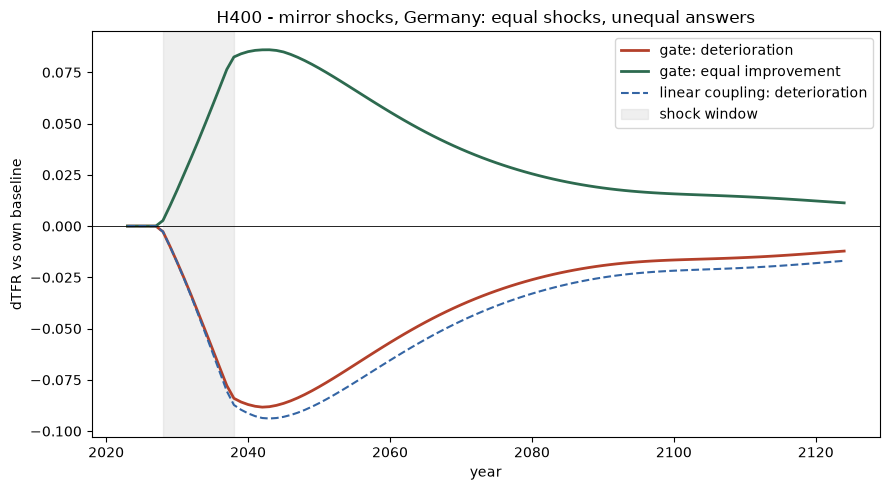

In [18]:
import matplotlib
matplotlib.rcParams.update({"figure.facecolor": "white", "font.size": 10})
figdir = Path("../reports/figures"); figdir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 5))
yrs = np.arange(2023, 2023 + YEARS)
ax.plot(yrs, D_G, lw=2, color="#b3402a", label="gate: deterioration")
ax.plot(yrs, U_G, lw=2, color="#2d6a4f", label="gate: equal improvement")
ax.plot(yrs, D_L, lw=1.5, ls="--", color="#3465a4", label="linear coupling: deterioration")
ax.axvspan(2028, 2038, color="#999", alpha=0.15, label="shock window")
ax.axhline(0, color="k", lw=0.6)
ax.set(title="H400 - mirror shocks, Germany: equal shocks, unequal answers",
       xlabel="year", ylabel="dTFR vs own baseline")
ax.legend(); fig.tight_layout(); fig.savefig(figdir / "nb38_misery_gate.png", dpi=150); plt.show()

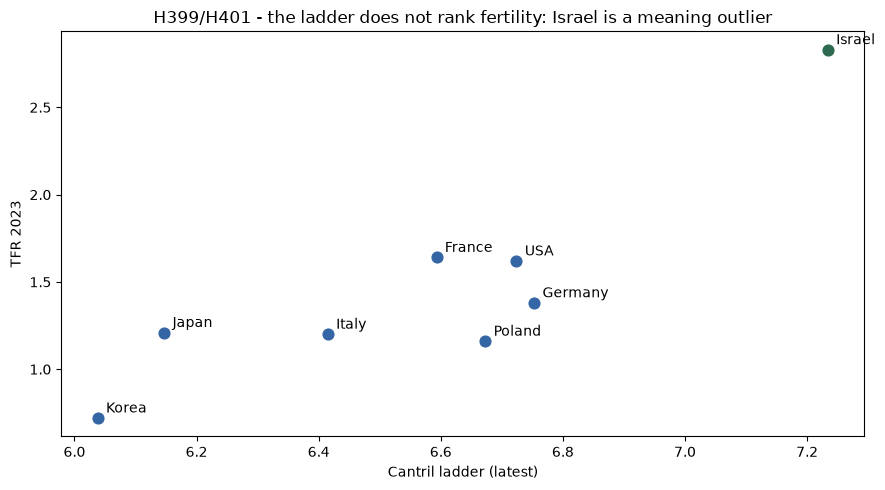

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
for nm in REGIONS:
    ax.scatter(LADDER[nm], em.REAL[nm][0], s=60, color="#2d6a4f" if nm == "Israel" else "#3465a4")
    ax.annotate(nm, (LADDER[nm], em.REAL[nm][0]), textcoords="offset points", xytext=(6, 4))
ax.set(title="H399/H401 - the ladder does not rank fertility: Israel is a meaning outlier",
       xlabel="Cantril ladder (latest)", ylabel="TFR 2023")
fig.tight_layout(); fig.savefig(figdir / "nb38_meaning_split.png", dpi=150); plt.show()

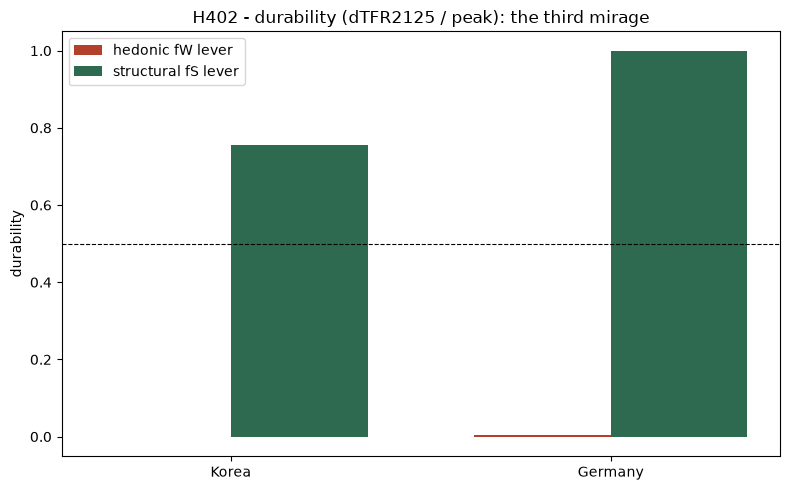

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
names = list(DUR)
x = np.arange(len(names))
ax.bar(x - 0.18, [DUR[n]["w_dur"] for n in names], 0.36, color="#b3402a", label="hedonic fW lever")
ax.bar(x + 0.18, [DUR[n]["s_dur"] for n in names], 0.36, color="#2d6a4f", label="structural fS lever")
ax.axhline(0.5, color="k", ls="--", lw=0.8); ax.set_xticks(x, names)
ax.set(title="H402 - durability (dTFR2125 / peak): the third mirage", ylabel="durability")
ax.legend(); fig.tight_layout(); fig.savefig(figdir / "nb38_mirage_durability.png", dpi=150); plt.show()

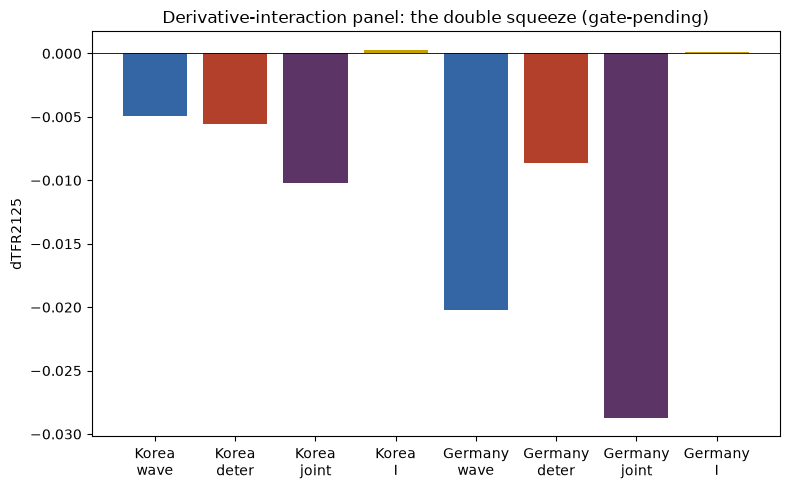

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
for nm, v in PANEL.items():
    ax.bar([f"{nm}\nwave", f"{nm}\ndeter", f"{nm}\njoint", f"{nm}\nI"],
           [v["wave"], v["deter"], v["joint"], v["I"]],
           color=["#3465a4", "#b3402a", "#5c3566", "#c4a000"])
ax.axhline(0, color="k", lw=0.6)
ax.set(title="Derivative-interaction panel: the double squeeze (gate-pending)", ylabel="dTFR2125")
fig.tight_layout(); fig.savefig(figdir / "nb38_double_squeeze.png", dpi=150); plt.show()

## Save verdicts

In [22]:
out = dict(round="E42", hypotheses=VERDICTS, panel=PANEL,
           anchors=dict(E0=E0_ATT, E_rate=E_RATE, ladder=LADDER, pen=PEN, eq=EQ),
           params=P_EW, floor_diag=FLOOR_DIAG,
           review=dict(
               round1=["records: REVISE (2 MAJOR + 2 MINOR) - fixed",
                       "methodology: REVISE (2 MAJOR + 9 MINOR) - fixed"],
               regrades={"H396": "SUPPORTED->PARTIAL (the null is by-construction)",
                         "H401": "PARTIAL->REFUTED (both sub-bars failed contradicting)"},
               floor_correction="baseline W-floor breaches: Italy/Japan/Korea/Poland (100% of strands), "
                                "Korea dominant at 33x the next gate mass; Germany never crosses - see floor_diag"))
if Path("../reports/nb38_e42_verdicts.json").exists():  # preserve the gate evidence across re-runs
    prev = json.load(open("../reports/nb38_e42_verdicts.json"))
    if "interaction_gate" in prev:
        out["interaction_gate"] = prev["interaction_gate"]
Path("../reports").mkdir(exist_ok=True)
with open("../reports/nb38_e42_verdicts.json", "w") as f:
    json.dump(out, f, indent=2)
rprint(f"[bold green]saved[/bold green] reports/nb38_e42_verdicts.json ({len(VERDICTS)} verdicts)")
for h, v in VERDICTS.items():
    rprint(f"  {h}: {v['verdict']}")

saved reports/nb38_e42_verdicts.json (10 verdicts)

H393: PARTIAL

H394: SUPPORTED

H395: SUPPORTED

H396: PARTIAL

...

H398: PARTIAL

H399: REFUTED

H400: PARTIAL

H401: REFUTED

H402: PARTIAL

## Conclusions

**Verdicts: 3 SUPPORTED / 5 PARTIAL / 2 REFUTED** (H394, H395, H397 supported; H393, H396, H398,
H400, H402 partial; H399, H401 refuted). Campaign totals move to 402 hypotheses across 42 rounds.
Two verdicts were re-graded by the round's adversarial review: H396 SUPPORTED -> PARTIAL (its null
is by-construction - the architecture contains no direct E wire, so the test could not fail) and
H401 PARTIAL -> REFUTED (both sub-bars failed in the contradicting direction, the H399 standard).

**Education is timing and matching, not a quantum dial.** The incarceration routing carries the
gradient in Korea but under the 75% pre-registration bar, and France's >1 tempo share is wire
interference from the sign-flipping equity-conditional quantum term, not tempo dominance (H393);
attainment with the cash-out wires off is inert BY CONSTRUCTION - the architecture routes every
education effect through named mechanisms, so the measured content is the income lever's >10x
magnitude and the marker-not-mechanism claim stands on E22's evidence (H396, re-graded at review);
the positional race makes expansion worse than income-routed expansion with the dE/dt wave biting
mid-flight (H394 - the endpoint contrast is partly confounded by the control arm's income
cash-out, so the clean positional evidence is the mid-flight transient); the gradient's sign is a
regime label wired through the equity term and surviving the coupled pipeline (H395); and cutting
the incarceration term beats cutting attainment 3/3 (H397).

**The make-them-happy lever is dead on three independent counts.** The hedonic-competition story
is REFUTED on its own bar (H399: the ladder ranks TFR even ex-Israel, rho +0.54); the hedonic
stimulus is not even a mirage but a null - the 2-year habituation transient is low-pass-filtered
by decade-scale fertility channels (H402: peak ~1e-4 under the bar; the durability half is
by-construction given the habituation stock, so the peak was the only discriminator); and the
fairly-fitted meaning split is REFUTED at n=8 (H401: LOO-RMSE 0.450 -> 0.542, strictly worse
out-of-sample, Israel residual grows) even though the single-W Israel residual (+0.94) confirms
one happiness dial cannot carry both Israel and Korea. What remains real: W matters exactly where
it is structural - the misery gate and the loss-averse derivative are live wires, but their bite
is POSITIONAL, and the floor diagnostics cell corrects the round's own first explanation: Germany's
baseline mean W bottoms near -0.12 and NEVER crosses the -0.15 floor (the gate opens only in the
shocked tail strands, a few percent of the direct S-channel response - the H400 null asymmetry is
an amplitude problem, not a saturated-regime problem), while the genuine baseline breaches live in
Italy, Japan, Korea and Poland (100% of strands), Korea dominant at 33x the next gate mass. The nonlinearity lives at
the floor crossing - geometry over magnitude.

**Interaction gate (both readings amended before recording).** The double-squeeze panel's
positive I (+0.00059/+0.00080 mid-century, K-converged across K=32-192) is a *multiplicative
composition cross-term* - the deterioration discounts the quantum factor while the education wave
discounts fec/tempo, and a product of discounts beats their sum - NOT shared-wire saturation
(I_rv ~ 0, I_tau ~ 0); the 2125 endpoint is relaxation-washed quantization noise and is not a
reportable magnitude. H398's headline USA broadcast share 0.66 is OVERTURNED as a bistable
well-crossing artifact (the broadcast wire tips USA's and France's norm across thN=0.25; France's
direct leg is additionally dead because a -0.01 penalty never opens the misery gate); Korea,
already in the high well, gives the honest marginal broadcast share 0.22. Named residuals for a
follow-up: the gWN dial-vs-switch sweep, the per-region well-posedness of the full-minus-direct
decomposition, and the triple wave x deterioration x broadcast run.

**For E42b (promotion question):** E earns no seat as a state variable - it is a proxy routing
through tau/S/q and its only irreducible content is the positional race dynamics; W earns a
conditional case - the misery gate, loss-averse derivative and broadcast wires are real couplings
with digest-grounded parameters, but they are regime-dependent (floor position, norm basin) - with
the baseline breach living in Korea, not Germany as first drafted - and the cross-sectional
meaning split is REFUTED, not merely unidentified. The promotion workflow decides against the
campaign bar: elegance must move the numbers.